<div style="background:linear-gradient(135deg,#42275a 0%,#734b6d 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">📊&nbsp; Uncertainty Quantification with Deep Ensembles</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">A point prediction without error bars is only half an answer. We train an <i>ensemble</i> of PINNs from different random seeds and use their disagreement as a practical, well-calibrated estimate of epistemic uncertainty.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#d6336c;color:#fff;padding:4px 8px;">advanced</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">uncertainty · ensembles</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">method</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">deep ensemble</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#603813;color:#fff;padding:4px 8px;">~2 min · CPU</span></span></div>

**Deep ensembles** are the simplest reliable UQ method: train the same model several times with
different initialisations, then report the **mean** as the prediction and the **standard deviation**
as the uncertainty. Where the members agree, we are confident; where they diverge, we are not.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#idea" style="color:#1a73e8;text-decoration:none;">1 · Why Ensembles</a></li>
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">2 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#train" style="color:#1a73e8;text-decoration:none;">3 · Training the Ensemble</a></li>
  <li style="margin:3px 0;"><a href="#bands" style="color:#1a73e8;text-decoration:none;">4 · Predictions with Error Bars</a></li>
  <li style="margin:3px 0;"><a href="#map" style="color:#1a73e8;text-decoration:none;">5 · An Uncertainty Map</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">6 · Takeaways</a></li>
  </ol>
</div>

<a id="idea"></a>

## 1 · Why Ensembles

<div style="background:#fdeef2;border-left:5px solid #d6336c;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>🔑 Key Idea.</b> Each member converges to a slightly different solution because of random initialisation and sampling. Their spread approximates the model's <b>epistemic uncertainty</b> — what it doesn't know due to limited training.
</div>

<a id="setup"></a>

## 2 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


<a id="train"></a>

## 3 · Training the Ensemble

We train a small ensemble of Burgers PINNs, each from a different seed.

In [2]:
from pinnlab.models import MLP
from pinnlab.solvers.raissi_improved import (
    BurgersConfig, TrainConfig, ContinuousPINN, burgers_residual)

cfg = BurgersConfig()
N_MEMBERS = 4

nt, nx = 60, 120
t_grid = np.linspace(cfg.tmin, cfg.tmax, nt, dtype=np.float32)
x_grid = np.linspace(cfg.xmin, cfg.xmax, nx, dtype=np.float32)
TT, XX = np.meshgrid(t_grid, x_grid, indexing="ij")

preds = []
for k in range(N_MEMBERS):
    torch.manual_seed(100 + k); np.random.seed(100 + k)
    pinn = ContinuousPINN(MLP(2, 4, 32, 1), DEVICE, burgers_residual, cfg)
    pinn.train(TrainConfig(n_u0=120, n_bc=80, n_f=1_000, adam_steps=1_000,
                           lbfgs_max_iter=0, seed=100 + k, track_losses=True),
               weights=(10.0, 1.0, 1.0))
    preds.append(pinn.predict(TT, XX))
    print(f"  member {k+1}/{N_MEMBERS} trained")

preds = np.stack(preds)               # (members, nt, nx)
mean = preds.mean(0)
std  = preds.std(0)
print(f"Ensemble ready: mean and std over {N_MEMBERS} members.")

  member 1/4 trained


  member 2/4 trained


  member 3/4 trained


  member 4/4 trained
Ensemble ready: mean and std over 4 members.


<a id="bands"></a>

## 4 · Predictions with Error Bars

At a fixed time slice we plot the ensemble mean with a ±2σ confidence band.

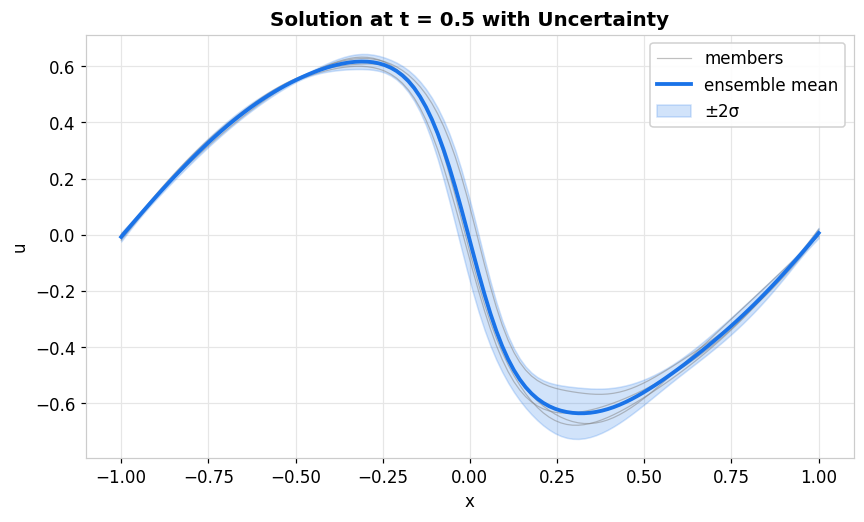

In [3]:
idx = np.argmin(np.abs(t_grid - 0.5))     # t = 0.5 slice
m, s = mean[idx], std[idx]

fig, ax = plt.subplots(figsize=(9, 5))
for k in range(N_MEMBERS):
    ax.plot(x_grid, preds[k, idx], color="gray", lw=0.8, alpha=0.5,
            label="members" if k == 0 else None)
ax.plot(x_grid, m, color=ACCENT, lw=2.5, label="ensemble mean")
ax.fill_between(x_grid, m - 2*s, m + 2*s, color=ACCENT, alpha=0.2, label="±2σ")
ax.set(title="Solution at t = 0.5 with Uncertainty", xlabel="x", ylabel="u")
ax.legend(); plt.show()

<a id="map"></a>

## 5 · An Uncertainty Map

Plotting σ over the whole domain reveals *where* the ensemble is unsure — typically along the steep front, exactly where PINNs struggle most.

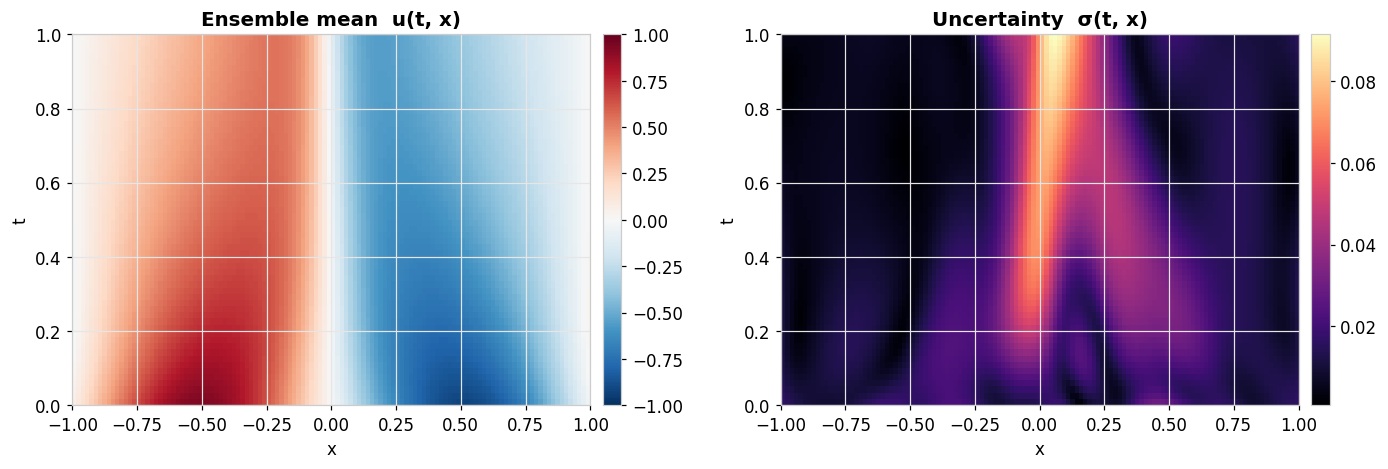

Mean uncertainty: 1.967e-02   |   Peak uncertainty: 9.140e-02


In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
im1 = a1.imshow(mean, extent=[cfg.xmin, cfg.xmax, cfg.tmin, cfg.tmax], origin="lower",
                aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
a1.set(title="Ensemble mean  u(t, x)", xlabel="x", ylabel="t"); fig.colorbar(im1, ax=a1, pad=0.02)

im2 = a2.imshow(std, extent=[cfg.xmin, cfg.xmax, cfg.tmin, cfg.tmax], origin="lower",
                aspect="auto", cmap="magma")
a2.set(title="Uncertainty  σ(t, x)", xlabel="x", ylabel="t"); fig.colorbar(im2, ax=a2, pad=0.02)
plt.tight_layout(); plt.show()
print(f"Mean uncertainty: {std.mean():.3e}   |   Peak uncertainty: {std.max():.3e}")

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> Bright bands in the σ-map flag regions to trust least — a cue for where to add collocation points or measurements next.
</div>

<a id="takeaways"></a>

## 6 · Takeaways

- A **deep ensemble** turns any PINN into an uncertainty-aware model with no architectural changes.
- The standard deviation across members is a practical proxy for **epistemic uncertainty**.
- Uncertainty concentrates where the physics is hard (sharp fronts) — useful for **active learning**
  and experimental design.
- The library also offers Bayesian and MC-dropout estimators (`pinnlab.uncertainty`) for
  alternative UQ flavours.

### 📚 References

1. Lakshminarayanan, B., Pritzel, A., & Blundell, C. (2017). *Simple and scalable predictive uncertainty estimation using deep ensembles*. NeurIPS.
2. Psaros, A. F. et al. (2023). *Uncertainty quantification in scientific machine learning*. J. Comput. Phys., 477, 111902.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>